<a href="https://colab.research.google.com/github/Pete-Reseacher/python-geoscience/blob/main/week4%2CEXCERCISE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QUESTION 1
# Using the Data2.las dataset provided, perform a complete modelling workflow following the same approach demonstrated in the Introductory Modelling lecture notebook.
# Your goal is to build a regression model that predicts Capillary Pressure (Pc) from the other available variables in the dataset.
# Evaluate the performance of the model using the following metrics:
# Mean Absolute Error (MAE)
# Root Mean Squared Error (RMSE)
# Coefficient of Determination (R²)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lasio as ls

#!pip install scikit-learn

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report,
ConfusionMatrixDisplay)


In [ ]:
# Load LAS file
las = ls.read("Data2.las")
df =  las.df()

In [ ]:
df.head()

,CALI,DT,GR,RESD,LLS,NPHI,RHOB
DEPT,,,,,,,
10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [ ]:
df = las.df().reset_index()

In [ ]:
df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN


In [ ]:
# Calculate Pc (added to df)

df["PHID"] = (2.65 - df["RHOB"]) / (2.65 - 1.0)
df["Pc"] = 10 * (df["PHID"] ** - 1.5)

In [ ]:
df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB,PHID,Pc
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
NULL_VALUE = float(las.well.NULL.value)

df.replace(NULL_VALUE, np.nan, inplace=True)

In [ ]:
df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB,PHID,Pc
0,10.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
1,10.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
2,11.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
3,11.5,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN
4,12.0,19.5,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop any row with missing values

df.dropna(inplace=True)

In [ ]:
df.head()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB,PHID,Pc
7841,3930.5,17.450001,42.300003,26.495501,77.460197,46.062901,0.5371,1.6142,0.627758,20.105369
7842,3931.0,17.549999,42.700001,25.612900,60.520000,47.109001,0.5371,1.6142,0.627758,20.105369
7843,3931.5,17.700001,40.799999,26.338600,58.020302,59.331699,0.5269,1.6142,0.627758,20.105369
7844,3932.0,17.900000,54.800003,25.631100,60.520000,70.619400,0.5170,1.5811,0.647818,19.178750
7845,3932.5,18.049999,54.599998,25.819401,60.520000,80.607300,0.5086,1.5584,0.661576,18.583634


In [ ]:
print(df.columns.tolist())


['DEPT', 'CALI', 'DT', 'GR', 'RESD', 'LLS', 'NPHI', 'RHOB', 'PHID', 'Pc']


In [ ]:
df.shape

(15175, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15175 entries, 7841 to 23021
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    15175 non-null  float64
 1   CALI    15175 non-null  float64
 2   DT      15175 non-null  float64
 3   GR      15175 non-null  float64
 4   RESD    15175 non-null  float64
 5   LLS     15175 non-null  float64
 6   NPHI    15175 non-null  float64
 7   RHOB    15175 non-null  float64
 8   PHID    15175 non-null  float64
 9   Pc      15175 non-null  float64
dtypes: float64(10)
memory usage: 1.3 MB


In [ ]:
df.describe()

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB,PHID,Pc
count,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000,15175.000000
mean,7726.305568,14.880928,115.110438,54.781433,30.449165,5.492070,0.312755,2.182191,0.283520,80.670415
std,2191.246990,3.324416,26.086174,23.073335,50.805323,12.028951,0.190060,0.151890,0.092055,260.024762
min,3930.500000,5.723400,13.900001,19.525400,0.053700,0.091400,-2.015800,1.266900,0.004970,13.030035
25%,5829.250000,12.142599,98.199997,36.759550,1.733800,1.781150,0.272150,2.142600,0.239879,58.640856
50%,7727.000000,13.497000,110.900002,43.622002,5.453100,3.520200,0.317000,2.196700,0.274727,69.445984
75%,9623.750000,17.122149,121.500000,75.262798,43.883499,6.416550,0.369750,2.254200,0.307515,85.116195
max,11520.500000,22.777199,260.700012,142.199493,1213.057373,341.103912,0.626800,2.641800,0.838242,28544.225395


In [ ]:
df.isna().sum()

DEPT    0
CALI    0
DT      0
GR      0
RESD    0
LLS     0
NPHI    0
RHOB    0
PHID    0
Pc      0
dtype: int64

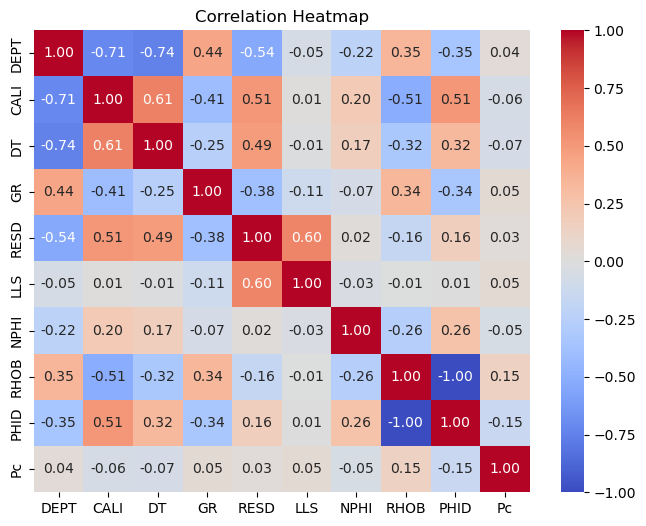

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Check your ["Pc"] value to know the min/max range to use.

df["Pc"].describe()

count    15175.000000
mean        80.670415
std        260.024762
min         13.030035
25%         58.640856
50%         69.445984
75%         85.116195
max      28544.225395
Name: Pc, dtype: float64

In [ ]:
# Check your ["PHID"] value to know the min/max range to use.

df["PHID"].describe()

count    15175.000000
mean         0.283520
std          0.092055
min          0.004970
25%          0.239879
50%          0.274727
75%          0.307515
max          0.838242
Name: PHID, dtype: float64

In [ ]:
ranges = {
    "CALI": (6, 20),
    "DT": (40, 240),
    "GR": (0, 150),
    "RESD": (0.2, 2000),
    "LLS": (0.2, 2000),
    "NPHI": (-0.15, 0.45),
    "RHOB": (1.95, 2.95),
    "PHID": (0.2, 1000),
    "Pc": (0.2, 2000)
}

df_clean = df.copy()

for col, (lo, hi) in ranges.items():
    if col in df_clean.columns:
        mask = df_clean[col].notna() & ((df_clean[col] <  lo) | (df_clean[col] > hi))
        print(col, "Out-of-rangement:", int(mask.sum()))
        df_clean.loc[mask, col] = np.nan

CALI Out-of-rangement: 1569
DT Out-of-rangement: 34
GR Out-of-rangement: 0
RESD Out-of-rangement: 82
LLS Out-of-rangement: 76
NPHI Out-of-rangement: 1111
RHOB Out-of-rangement: 773
PHID Out-of-rangement: 1690
Pc Out-of-rangement: 6


In [ ]:
df.isna().sum()

DEPT    0
CALI    0
DT      0
GR      0
RESD    0
LLS     0
NPHI    0
RHOB    0
PHID    0
Pc      0
dtype: int64

In [ ]:
df_clean.isna().sum()

DEPT       0
CALI    1569
DT        34
GR         0
RESD      82
LLS       76
NPHI    1111
RHOB     773
PHID    1690
Pc         6
dtype: int64

In [ ]:
target = "Pc"
features = ["CALI", "DT", "GR", "LLS", "NPHI", "RHOB", "RESD"]

depth_col = "DEPT"

model_df = df_clean[features + [target, depth_col]].copy()
reg_df = model_df.dropna(subset=features + [target]).copy()

In [ ]:
reg_df.head()

,CALI,DT,GR,LLS,NPHI,RHOB,RESD,Pc,DEPT
7964,19.15,57.399998,23.571100,2.3469,0.3883,2.0429,1.3630,44.805947,3992.0
7965,19.10,67.599998,25.473600,1.9242,0.4387,2.0511,0.8341,45.729291,3992.5
7974,19.50,162.699997,35.584202,0.6135,0.3250,2.1017,0.2101,52.203381,3997.0
7975,19.60,163.000000,36.689899,3.9638,0.2839,2.1919,60.5200,68.357394,3997.5
7976,19.35,164.700012,37.687599,2.0985,0.2784,2.1709,60.5200,63.912599,3998.0


In [ ]:
df.sample(5)

,DEPT,CALI,DT,GR,RESD,LLS,NPHI,RHOB,PHID,Pc
18130,9075.0,12.461700,103.199997,59.974800,1.2203,1.1036,0.3282,2.1171,0.322970,54.482539
8337,4178.5,15.738300,140.199997,46.155701,50.4716,8.0347,0.3483,2.2384,0.249455,80.262529
18688,9354.0,12.909400,109.199997,46.716999,0.8051,1.0822,0.3403,2.1645,0.294242,62.653028
10649,5334.5,18.685999,169.399994,44.552299,29.2960,5.8980,0.3508,2.1629,0.295212,62.344577
14786,7403.0,11.918300,110.799995,63.572399,5.6888,4.3936,0.3165,2.2500,0.242424,83.779146


In [ ]:
# Define features (X) and target (y)

X = reg_df[features]
y = reg_df[target]

# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("REG data:", reg_df.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


REG data: (12810, 9)
Train shape: (10248, 7)
Test shape: (2562, 7)


In [ ]:
lin_model = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)


In [ ]:
# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2 = r2_score(y_test, y_pred_lin)

In [ ]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# Note, Same as.....
# print (f"Mean Absolute Error (MAE): {mae:.2f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
# print(f"Coefficient of Determination (R2): {r2:.2f}")

MAE: 8.77689230574273
RMSE: 14.04472990358896
R2: 0.8296602569953885


In [ ]:
lr = lin_model.named_steps["model"]

intercept = lr.intercept_
coefficients = lr.coef_

features = X_train.columns

equation = f"Pc = {intercept:.4f}"

for coef, feature in zip(coefficients, features):
    equation += f" + ({coef:.4f} * {feature})"

    print(equation)

Pc = 81.7727 + (2.9000 * CALI)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT) + (2.4860 * GR)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT) + (2.4860 * GR) + (1.7933 * LLS)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT) + (2.4860 * GR) + (1.7933 * LLS) + (-0.8577 * NPHI)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT) + (2.4860 * GR) + (1.7933 * LLS) + (-0.8577 * NPHI) + (31.1351 * RHOB)
Pc = 81.7727 + (2.9000 * CALI) + (-0.3293 * DT) + (2.4860 * GR) + (1.7933 * LLS) + (-0.8577 * NPHI) + (31.1351 * RHOB) + (-2.8296 * RESD)


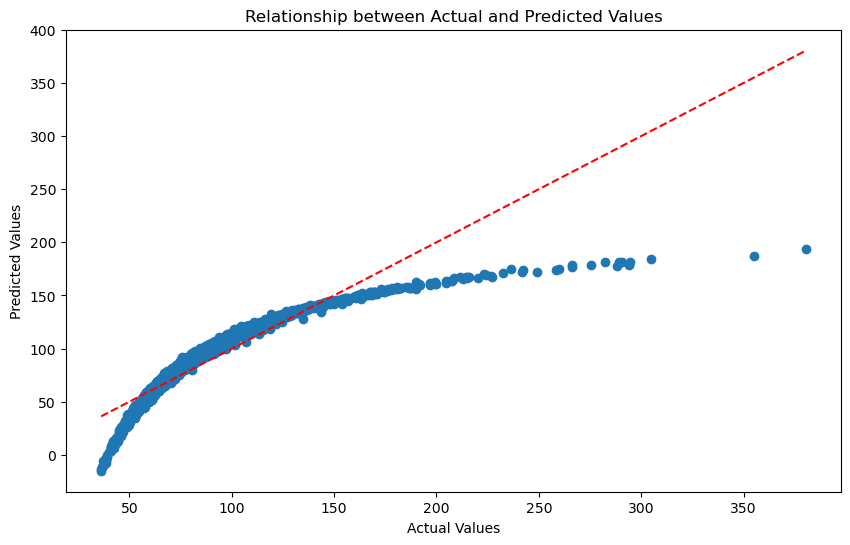

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred_lin)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Relationship between Actual and Predicted Values")
plt.show()

In [ ]:
missing_target = model_df[model_df[target].isna()].copy()
missing_target = missing_target.dropna(subset=features)

print("No of rows for missing Pc:", missing_target.shape)


No of rows for missing Pc: (6, 9)


In [ ]:
missing_target.head()

,CALI,DT,GR,LLS,NPHI,RHOB,RESD,Pc,DEPT
11014,13.355100,91.599998,34.174500,46.119801,0.0223,2.6339,88.369003,NaN,5517.0
13449,13.177200,42.300003,33.700100,33.549400,0.0169,2.6197,69.525597,NaN,6734.5
13450,13.179701,42.300003,30.450701,57.833099,0.0038,2.6418,214.856003,NaN,6735.0
13451,13.115499,107.299995,27.976299,60.068298,0.0014,2.6301,291.001099,NaN,6735.5
13452,13.186199,99.900002,30.660299,46.394299,0.0014,2.6095,232.089401,NaN,6736.0


In [ ]:
row = missing_target[missing_target[depth_col] == missing_target.iloc[0][depth_col]][features]

pred_lin = lin_model.predict(row)

print(f"Predicted: {pred_lin[0]:.3f}")

Predicted: 239.319
